# 03 - Back-EMF constant two ways

## Purpose

This notebook is the third in the series. It measures the back-EMF constant
$K_e$ of the motor, the voltage the winding generates per unit of speed, by
two routes that rest on different physics and different samples of the same
hardware, and it examines a third candidate channel that the data rejects.

This notebook has three jobs:

1. Measure $K_e$ by two independent routes and test their agreement
   (sections 5, 7 and 8).
2. Characterize the direct back-EMF channels, the terminal voltage read
   while the bridge leaves the winding floating, in the fast-decay drive
   grid (section 6) and in the coast segments (section 7).
3. Record the spread of every estimate across recordings (sections 5 to 7).

The dataset is three test series on one servo powered from a 2-cell lithium
battery. Speed is the derivative of the pot wiper voltage, in wiper volts
per second, as in notebook 00. The gear ratio between motor and wiper is
not known here, so $K_e$ is expressed in volts per wiper volt per second
and no claim is made about the motor shaft constant.


## 1. Test setup

The device under test and the signal chain are those of notebook 00,
section 1: an SG90-class hobby servo with replacement electronics, a
brushed DC motor behind an H-bridge at 20 kHz PWM, a pot wiper on the
output shaft read directly by the 12-bit ADC, a 33 mOhm shunt in the motor
return path with an amplifier of gain 15.0, and both motor terminals read
through 20 kOhm / 10 kOhm dividers. One frame of raw ADC samples is
streamed per 50 us control period.

Two facts about the bridge matter here.

- During the ON portion of a PWM period the bridge connects one terminal to
  the supply and the other to ground through the shunt.
- During the OFF portion the bridge has two modes. **Slow decay** closes
  both low-side switches and shorts the winding, so both terminals sit near
  ground and the winding current keeps circulating. **Fast decay** opens all
  four switches. The winding current then returns to the supply through the
  body diodes, during which the terminal that carries the current out of the
  winding sits one diode drop above the supply and the shunt reads negative.
  Once the current reaches zero the winding floats and the terminals carry
  the open-circuit back-EMF.

A **coast** segment is fast decay held at zero duty, so the winding floats
for the whole segment. A **brake** segment is slow decay at zero duty, so
the winding stays shorted.

Each sample row carries a shunt reading and both terminal readings taken at
one fixed point of the PWM period, the **crest scan**, plus a second shunt
reading from the opposite point of the period, the **trough scan**. Under
slow decay the crest scan falls inside the ON portion once the drive width
reaches 160 of the 1200 timer ticks (13.3% duty), and the firmware marks
those samples valid. Under fast decay the crest scan falls in the OFF
portion (notebook 01, section 5.3).

### 1.1 Model and routes

The winding obeys

$$v = R\,i + L\,\frac{di}{dt} + K_e\,\omega$$

with $v$ the terminal voltage, $i$ the winding current, $R$ the winding
resistance (brushes included), $L$ the winding inductance, $\omega$ the
speed and $K_e$ the back-EMF constant. Averaged over one PWM period at
steady speed the inductive term averages to zero. Under slow decay the OFF
portion applies zero volts, so the mean terminal voltage is the duty times
the ON-portion terminal difference:

$$\bar v = D\,(v_{\mathrm{drv}} - v_{\mathrm{idle}}) = R\,\bar i + K_e\,\omega$$

With the winding open, $i = 0$ and the terminal voltage equals
$K_e\,\omega$ directly.

- **Route A** uses slow-decay drive steps at steady speed. The mean
  voltage, mean current and speed of every valid step are fitted jointly
  to the averaged equation.
- **Route C** uses the coast segments. The floating terminal voltage is
  regressed on the instantaneous speed as the mechanism spins down.
- The **fast-decay crest sample**, one terminal reading per PWM period
  taken in the OFF portion, is the candidate for a direct back-EMF channel
  inside a drive step. Section 6 tests it against speed and current.

Route C and the candidate share the terminal channel and the
floating-winding physics. Route A shares nothing with them beyond the pot
wiper and the terminal divider.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
identical to notebook 00.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM period | 1200 timer ticks |
| Duty encoding | signed, 32767 = 100% |
| Sampling validity threshold | 160 timer ticks = 13.3% duty |

Two caveats:

- The ADC reference is the chip's VDD supply. The 3.300 V figure is the
  design value, and the actual VDD of this unit was not measured. Every
  voltage below scales linearly with the true VDD. $K_e$ is a ratio of a
  terminal voltage to a wiper voltage per second, and both scale with VDD,
  so $K_e$ itself does not depend on it. $R$ does.
- The divider, shunt, and gain are design values. Component tolerances
  were not measured, and absolute voltages and currents carry them.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_PERIOD_TICKS = 1200     # timer ticks per PWM period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
V_TERM_PER_COUNT = V_ADC_PER_COUNT * (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt

pd.DataFrame([
    {"channel": "pot wiper", "factor": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"channel": "motor terminal", "factor": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"channel": "motor current", "factor": A_PER_COUNT * 1e3, "unit": "mA per count"},
]).set_index("channel").round(4)


,factor,unit
channel,,
pot wiper,0.8057,mV per count
motor terminal,2.4170,mV per count
motor current,1.6276,mA per count


## 3. Capture method

Three test series, all from the same servo and the same battery, streamed
at the full 20 kHz sample rate with a CRC on every frame. Corrupted frames
are dropped and counted, so corruption turns into missing samples.

- **Slow-decay grid.** The 41-segment recording of notebook 00: a
  one-second baseline with the motor undriven, then 80 ms constant-duty
  drive steps from 5% to 100% in 5% increments, forward then reverse, each
  preceded by a repositioning move toward the far end of travel and
  followed by 500 ms of rest. Fifteen recordings, the ten battery
  recordings of notebook 00 and five further ones with the same method.
- **Fast-decay grid.** The same 41-segment grid with the bridge in fast
  decay during the drive steps. Five recordings.
- **Spin-down.** A one-second baseline, then for each direction the
  sequence drive 20% for 80 ms, coast 400 ms, drive 20%, brake 400 ms,
  drive 30%, coast, drive 30%, brake, drive 40%, coast, drive 40%, brake.
  Twenty-five segments per recording, five recordings. The zero-duty
  segments alternate coast and brake and are identified by their position
  in the recorded schedule.

**Data acceptance.** Any recording with a dropped frame was discarded and
re-run. Section 4 re-verifies this from the tick column.

Each row of a recording is one 50 us sample: segment number, commanded
duty, direction, tick counter, the validity flag, and the raw channels
(position, crest-scan shunt, trough-scan shunt, both crest-scan terminals).


In [2]:
TELEMETRY = Path("telemetry/sg90")

def load(csv, meta):
    df = pd.read_csv(csv)
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    return df, json.loads(Path(meta).read_text())

def capture_dirs(base):
    return sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1]))

slow, fast, spin = {}, {}, {}
for d in capture_dirs(TELEMETRY / "2s"):
    slow[f"2s/{d.name}"] = load(d / "sweep.csv.gz", d / "meta.json")
for d in capture_dirs(TELEMETRY / "bridge"):
    slow[f"bridge/{d.name}"] = load(d / "slow.csv.gz", d / "slow.meta.json")
    fast[f"bridge/{d.name}"] = load(d / "fast.csv.gz", d / "fast.meta.json")
    spin[f"bridge/{d.name}"] = load(d / "spindown.csv.gz", d / "spindown.meta.json")

pd.DataFrame({"recordings": [len(slow), len(fast), len(spin)]},
             index=["slow-decay grid", "fast-decay grid", "spin-down"])


,recordings
slow-decay grid,15
fast-decay grid,5
spin-down,5


## 4. Data integrity

One frame carries 16 consecutive samples, so a dropped frame appears as a
16-tick jump inside a segment. The table recomputes the missing-sample
count of every recording from the tick column. It also reports the lowest
duty step at which the validity flag is set, which route A relies on.


In [3]:
def integrity(recs, series):
    rows = []
    for name, (df, _) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        steps = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid=("window_valid", "mean"))
        steps = steps[steps["d"] != 0]
        rows.append({
            "series": series,
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
            "flag_set_from_pct": steps[steps["valid"] > 0.5]["d"].abs().min().round(),
        })
    return pd.DataFrame(rows)

pd.concat([integrity(slow, "slow-decay grid"),
           integrity(fast, "fast-decay grid"),
           integrity(spin, "spin-down")], ignore_index=True)


,series,recording,samples,segments,missing_samples,flag_set_from_pct
0,slow-decay grid,2s/capture-1,84000,41,0,15.0
1,slow-decay grid,2s/capture-2,84000,41,0,15.0
2,slow-decay grid,2s/capture-3,84000,41,0,15.0
3,slow-decay grid,2s/capture-4,84000,41,0,15.0
4,slow-decay grid,2s/capture-5,84000,41,0,15.0
5,slow-decay grid,2s/capture-6,84000,41,0,15.0
6,slow-decay grid,2s/capture-7,84000,41,0,15.0
7,slow-decay grid,2s/capture-8,84000,41,0,15.0
8,slow-decay grid,2s/capture-9,84000,41,0,15.0
9,slow-decay grid,2s/capture-10,84000,41,0,15.0


Every recording has zero missing samples. In every grid recording the
flag is set from the 15% step up and clear at 10%, consistent with the
160-tick threshold. The spin-down drive steps are all at or above 20%.

## 5. Route A: slow-decay drive steps

### 5.1 Per-step quantities

For every drive step with the validity flag set:

- **Applied voltage** $\bar v = D\,(v_{\mathrm{drv}} - v_{\mathrm{idle}})$.
  The driven terminal is the 90th percentile of its valid crest-scan
  samples, the supply estimate of notebook 00, section 6.2. The idle
  terminal is the median of its valid samples (the low-side switch and
  shunt drop). Both are in volts at the terminals.
- **Current** $\bar i$ is the mean valid crest-scan shunt reading minus
  the baseline offset of the same recording (notebook 00, section 5.2),
  signed by direction. The crest scan sits at the centre of the ON portion,
  and the current ripple within a period is close to triangular, so the
  centre sample is taken as the period mean.
- **Speed** $\omega$ is the slope of a least-squares line through the last
  60% of the step's wiper trace, the method of notebook 00, section 6.3.

Notebook 00 restricted the supply estimate to 25% duty and above. In these
recordings the crest-scan terminals read the supply at every flagged step,
so the restriction is dropped and the 15% and 20% steps are included.


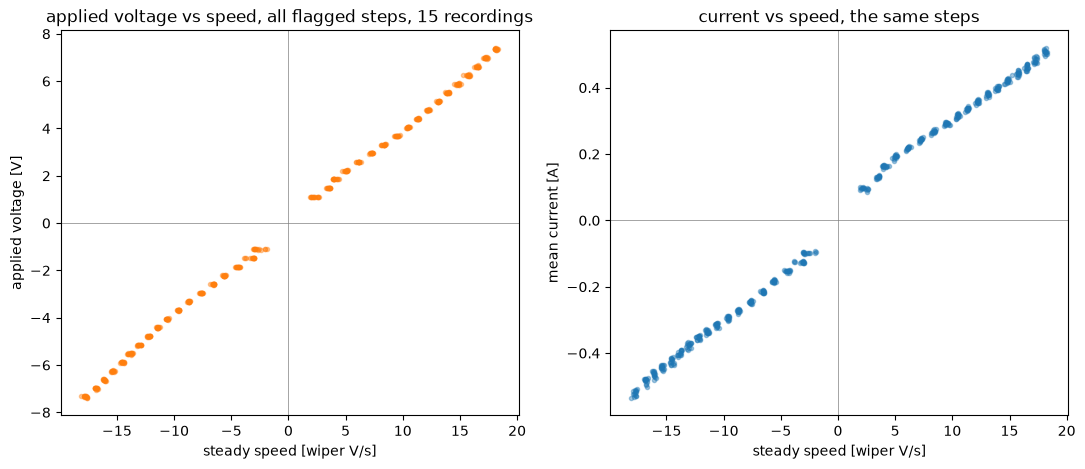

,speed_Vps,valid_frac,rail_V,idle_V,current_A,applied_V
duty_pct,,,,,,
14.999847,1.996,0.999,7.473,0.063,0.095,1.112
19.998779,3.383,0.999,7.464,0.065,0.128,1.480
24.997711,3.997,0.999,7.454,0.068,0.162,1.846
29.999695,4.924,0.999,7.449,0.073,0.190,2.213
34.998627,6.052,0.999,7.444,0.077,0.216,2.578
39.997559,7.203,0.999,7.440,0.080,0.241,2.944
44.999542,8.220,0.999,7.437,0.082,0.267,3.310
49.998474,9.328,0.999,7.435,0.085,0.297,3.675
54.997406,10.369,0.999,7.430,0.087,0.319,4.038


In [4]:
def current_bias(df):
    return df[df["seg"] == 0]["current_raw"].mean()

def step_speed(seg):
    n = len(seg)
    tail = seg.iloc[int(n * 0.4):]
    t = (tail["tick"] - tail["tick"].iloc[0]) / TICK_HZ
    return np.polyfit(t, tail["pos"] * V_ADC_PER_COUNT, 1)[0]

def drive_steps(df):
    bias = current_bias(df)
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        drv, idle = ("vmotor_a", "vmotor_b") if d > 0 else ("vmotor_b", "vmotor_a")
        v = seg[seg["window_valid"] == 1]
        row = {"duty_pct": d, "speed_Vps": step_speed(seg),
               "valid_frac": seg["window_valid"].mean()}
        if len(v) >= 100:
            row.update({
                "rail_V": v[drv].quantile(0.9) * V_TERM_PER_COUNT,
                "idle_V": v[idle].median() * V_TERM_PER_COUNT,
                "current_A": np.sign(d) * (v["current_raw"].mean() - bias) * A_PER_COUNT,
            })
        out.append(row)
    s = pd.DataFrame(out)
    s["applied_V"] = s["duty_pct"] / 100.0 * (s["rail_V"] - s["idle_V"])
    return s

steps_a = {name: drive_steps(df).dropna(subset=["current_A"])
           for name, (df, _) in slow.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, s in steps_a.items():
    axes[0].plot(s["speed_Vps"], s["applied_V"], "o", ms=3, alpha=0.4, color="tab:orange")
    axes[1].plot(s["speed_Vps"], s["current_A"], "o", ms=3, alpha=0.4, color="tab:blue")
axes[0].set_xlabel("steady speed [wiper V/s]")
axes[0].set_ylabel("applied voltage [V]")
axes[0].set_title("applied voltage vs speed, all flagged steps, 15 recordings")
axes[1].set_xlabel("steady speed [wiper V/s]")
axes[1].set_ylabel("mean current [A]")
axes[1].set_title("current vs speed, the same steps")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
plt.show()

steps_a["bridge/capture-1"].set_index("duty_pct").round(3)


The right panel is the problem of route A in one picture. Current and
speed rise together across the grid, so the two regressors of the joint
fit are nearly proportional and the fit can trade $R$ against $K_e$ with
little change in residual. Section 5.3 quantifies this.

### 5.2 Joint fit

Per recording, $\bar v = R\,\bar i + K_e\,\omega$ is fitted by least
squares over all flagged steps of both directions with no intercept. The
signs are consistent by construction, since reverse steps carry negative
voltage, negative current and negative speed.


In [5]:
def fit_route_a(s):
    A = np.column_stack([s["current_A"], s["speed_Vps"]])
    x, _, _, sv = np.linalg.lstsq(A, s["applied_V"], rcond=None)
    resid = s["applied_V"] - A @ x
    return {"R_ohm": x[0], "Ke_V_per_Vps": x[1],
            "rms_resid_V": np.sqrt(np.mean(resid ** 2)),
            "corr_i_w": np.corrcoef(s["current_A"], s["speed_Vps"])[0, 1],
            "condition": sv[0] / sv[1], "steps": len(s)}

fits_a = pd.DataFrame([{"recording": n, **fit_route_a(s)} for n, s in steps_a.items()])
fits_a.set_index("recording").round(4)


,R_ohm,Ke_V_per_Vps,rms_resid_V,corr_i_w,condition,steps
recording,,,,,,
2s/capture-1,1.3125,0.3640,0.1363,0.9980,544.0676,36
2s/capture-2,1.6515,0.3532,0.1513,0.9979,523.9478,36
2s/capture-3,2.1710,0.3374,0.1578,0.9978,513.9254,36
2s/capture-4,0.1584,0.3981,0.1161,0.9984,603.8474,36
2s/capture-5,2.0193,0.3401,0.1351,0.9980,538.6312,36
2s/capture-6,1.8772,0.3433,0.1461,0.9978,508.2804,36
2s/capture-7,2.5569,0.3243,0.1346,0.9978,511.3677,36
2s/capture-8,1.7891,0.3489,0.1322,0.9983,584.2571,36
2s/capture-9,1.6995,0.3514,0.1448,0.9977,504.7870,36


In [6]:
summary_a = fits_a[["R_ohm", "Ke_V_per_Vps"]].agg(["mean", "std", "min", "max"]).T
summary_a["spread_pct"] = summary_a["std"] / summary_a["mean"].abs() * 100
summary_a.round(4)


,mean,std,min,max,spread_pct
R_ohm,1.8593,0.6861,0.1584,3.1974,36.9016
Ke_V_per_Vps,0.3461,0.0209,0.3064,0.3981,6.0482


### 5.3 Collinearity and a sensitivity check

The correlation between current and speed across the steps of a recording
is above 0.997 and the condition number of the design matrix is above 500.
The joint fit therefore pins one combination of $R$ and $K_e$ and leaves
the split between them weak. Two checks make this concrete.

First, $R$ is fixed at the median of the joint fits and $K_e$ alone is
refitted per recording. Second, for one recording $K_e$ is stepped through
a grid, $R$ is refitted at each value, and the residual is tabulated. A
shallow valley means the data cannot choose.


In [7]:
R_MEDIAN = fits_a["R_ohm"].median()

def ke_at_fixed_r(s, r):
    return np.sum(s["speed_Vps"] * (s["applied_V"] - r * s["current_A"])) / np.sum(s["speed_Vps"] ** 2)

ke_fixed = pd.Series({n: ke_at_fixed_r(s, R_MEDIAN) for n, s in steps_a.items()})

s = steps_a["bridge/capture-1"]
rows = [{"Ke_fixed": "R fixed at joint median", "R_refit_ohm": R_MEDIAN,
         "rms_resid_V": np.nan, "Ke_mean_15_recordings": ke_fixed.mean(),
         "Ke_std": ke_fixed.std(), "Ke_spread_pct": ke_fixed.std() / ke_fixed.mean() * 100}]
for ke in np.arange(0.15, 0.50, 0.05):
    r = np.sum(s["current_A"] * (s["applied_V"] - ke * s["speed_Vps"])) / np.sum(s["current_A"] ** 2)
    resid = s["applied_V"] - r * s["current_A"] - ke * s["speed_Vps"]
    rows.append({"Ke_fixed": f"{ke:.2f} (bridge/capture-1)", "R_refit_ohm": r,
                 "rms_resid_V": np.sqrt(np.mean(resid ** 2))})
pd.DataFrame(rows).set_index("Ke_fixed").round(4).fillna("")


,R_refit_ohm,rms_resid_V,Ke_mean_15_recordings,Ke_std,Ke_spread_pct
Ke_fixed,,,,,
R fixed at joint median,1.7891,,0.3482,0.0012,0.3572
0.15 (bridge/capture-1),8.4432,0.1734,,,
0.20 (bridge/capture-1),6.7598,0.1509,,,
0.25 (bridge/capture-1),5.0764,0.134,,,
0.30 (bridge/capture-1),3.3930,0.1249,,,
0.35 (bridge/capture-1),1.7096,0.1253,,,
0.40 (bridge/capture-1),0.0262,0.1352,,,
0.45 (bridge/capture-1),-1.6572,0.1527,,,


Findings:

- The joint fit gives $K_e$ = 0.35 V per wiper V/s with a 6% spread across
  15 recordings, and $R$ = 1.9 Ohm with a 37% spread. $R$ is poorly
  determined.
- With $R$ fixed, $K_e$ repeats to 0.3% across recordings. The recording
  spread of the joint fit is a fitting artefact of the collinearity. The
  hardware repeats.
- The residual valley is shallow. Moving $K_e$ from 0.30 to 0.40 changes
  the rms residual from 0.125 V to 0.135 V while $R$ swings from 3.4 Ohm to
  0.0 Ohm. Route A on its own supports any $K_e$ from about 0.30 to 0.40
  with the matching $R$, and pins the combination
  $R + 34\,K_e \approx 13.5$ Ohm far better than either term.
- The residuals are structured, positive at the lowest and highest duties
  and negative in the middle, so the averaged equation with two constants
  does not describe the steps to better than about 0.1 V. Notebook 00
  showed the slowest steps are still accelerating at the end of the 80 ms
  window, which biases their speeds low and contributes to this.

## 6. The fast-decay crest sample, a rejected candidate

Under fast decay the crest scan falls in the OFF portion of the period.
If the winding current has died by then, the sample should read the
open-circuit back-EMF while the step's speed is known, which would give a
direct channel inside a drive step. Notebook 01, section 5.3, examined
this reading in the same recordings and found it on the terminal driven
low, whereas the coast segments put the back-EMF on the terminal driven
high. The test here is the simplest one. For the 10% to 40% steps of the
fast-decay grid, the reading is plotted against the step's steady speed
and against the drive current (the trough-scan shunt, which sits in the
ON portion under fast decay).


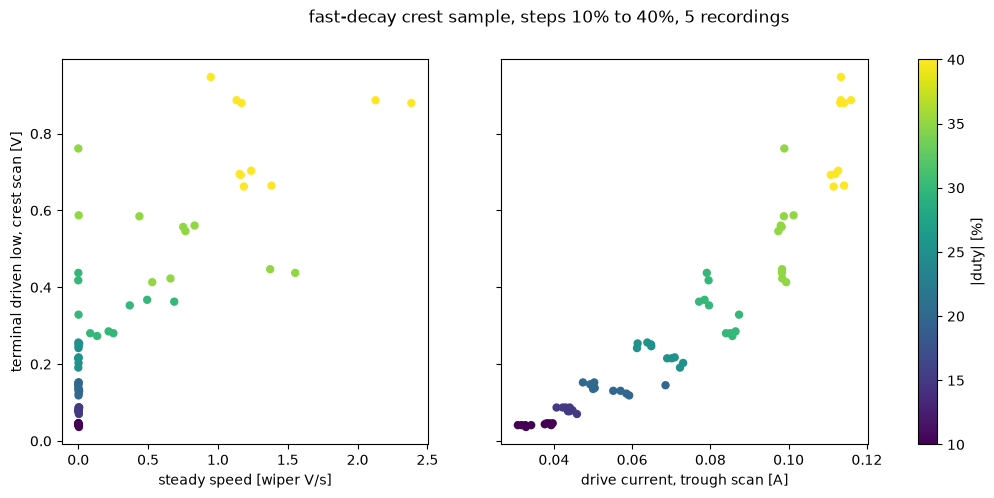

,steps,speed_mean_Vps,speed_max_Vps,reading_mean_V,reading_min_V,reading_max_V,drive_current_A,corr_reading_speed_within_duty
duty_mag,,,,,,,,
10,10,0.002,0.005,0.042,0.036,0.046,0.036,NaN
15,10,0.003,0.007,0.081,0.070,0.087,0.044,NaN
20,10,0.002,0.006,0.137,0.118,0.152,0.055,NaN
25,10,0.002,0.007,0.229,0.191,0.256,0.067,NaN
30,10,0.224,0.687,0.339,0.273,0.437,0.082,-0.034
35,10,0.691,1.553,0.532,0.413,0.761,0.099,-0.663
40,10,1.389,2.385,0.790,0.662,0.947,0.113,0.269


In [8]:
def fast_steps(df):
    bias = current_bias(df)
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        low = "vmotor_b" if d > 0 else "vmotor_a"
        out.append({
            "duty_pct": d,
            "duty_mag": round(abs(d)),
            "speed_Vps": abs(step_speed(seg)),
            "reading_V": seg[low].median() * V_TERM_PER_COUNT,
            "drive_current_A": (seg["current_trough"].mean() - bias) * A_PER_COUNT,
        })
    return pd.DataFrame(out)

steps_b = pd.concat([fast_steps(df).assign(recording=n) for n, (df, _) in fast.items()],
                    ignore_index=True)
sel = steps_b[(steps_b["duty_mag"] >= 10) & (steps_b["duty_mag"] <= 40)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, x, xlabel in [(axes[0], "speed_Vps", "steady speed [wiper V/s]"),
                      (axes[1], "drive_current_A", "drive current, trough scan [A]")]:
    sc = ax.scatter(sel[x], sel["reading_V"], c=sel["duty_mag"], cmap="viridis", s=25)
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("terminal driven low, crest scan [V]")
fig.colorbar(sc, ax=axes, label="|duty| [%]")
fig.suptitle("fast-decay crest sample, steps 10% to 40%, 5 recordings")
plt.show()

by_duty = sel.groupby("duty_mag").agg(
    steps=("speed_Vps", "size"),
    speed_mean_Vps=("speed_Vps", "mean"),
    speed_max_Vps=("speed_Vps", "max"),
    reading_mean_V=("reading_V", "mean"),
    reading_min_V=("reading_V", "min"),
    reading_max_V=("reading_V", "max"),
    drive_current_A=("drive_current_A", "mean"),
)
by_duty["corr_reading_speed_within_duty"] = sel.groupby("duty_mag").apply(
    lambda g: np.corrcoef(g["speed_Vps"], g["reading_V"])[0, 1] if g["speed_Vps"].std() > 0.01 else np.nan,
    include_groups=False)
by_duty.round(3)


Findings:

- From 10% to 25% the servo does not move (speed under 0.01 wiper V/s in
  every recording) while the reading climbs from 0.04 V to 0.23 V with
  duty. A back-EMF is zero at zero speed.
- At 35%, where some recordings moved and some stalled, the reading falls
  as speed rises within the duty (correlation -0.66 across the ten steps).
  The stalled recordings read higher.
- Against the drive current the reading is a single rising curve across
  all duties. Against speed it is a ladder of duty levels.

The reading tracks the winding current and sits on the wrong terminal. It
is not a back-EMF, and no $K_e$ is taken from it. In this scan geometry the
direct back-EMF is available only from the coast segments, where the
winding floats for the whole segment and no PWM edge precedes the sample.

## 7. Route C: coast-down

### 7.1 Method

Within each coast segment the winding floats for 400 ms while the
mechanism spins down. The convention follows notebook 01: the back-EMF
$e$ is three times the tap voltage of the terminal that was driven high
in the preceding drive step, signed by direction, and the samples from the
third sample of the segment onward are used. The histogram below justifies
the third sample. It pools the terminal sum $v_A + v_B$ of every coast
sample of all 30 segments, split by position in the segment. The first
two samples sit at the supply plus a diode drop (the body-diode phase,
about 3400 counts) and every later sample sits far below.


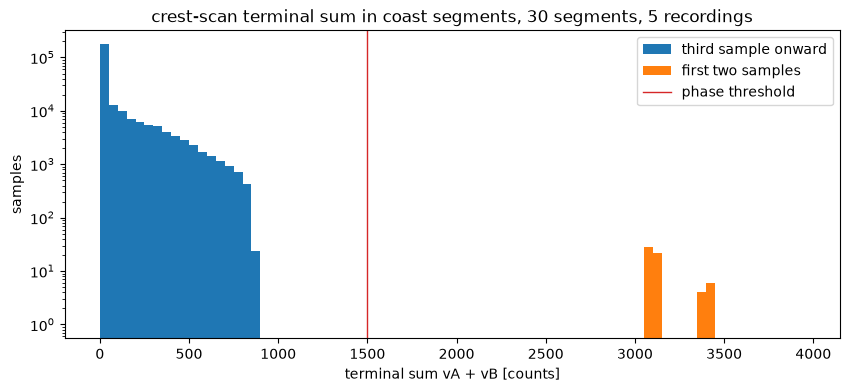

,samples,min_counts,max_counts,above_threshold
first two samples,60,3072,3420,60
third sample onward,239940,0,3417,6


In [9]:
def schedule_kinds(meta):
    kinds = []
    for _ in meta["dirs"]:
        level = None
        for entry in meta["schedule"]:
            if ":" in entry:
                kinds.append((entry.split(":")[0], level))
            else:
                level = float(entry)
                kinds.append(("drive", level))
    return kinds

def coast_segments(df, meta):
    kinds = schedule_kinds(meta)
    for seg_id, seg in df.groupby("seg"):
        if seg_id > 0 and kinds[seg_id - 1][0] == "coast":
            yield seg_id, kinds[seg_id - 1][1], seg

SUM_BACK_EMF_MAX = 1500      # counts, half the supply, inside the empty band below

first_two, later = [], []
for df, meta in spin.values():
    for _, _, seg in coast_segments(df, meta):
        total = (seg["vmotor_a"] + seg["vmotor_b"]).to_numpy()
        first_two.append(total[:2])
        later.append(total[2:])
first_two, later = np.concatenate(first_two), np.concatenate(later)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(0, 4000, 50)
ax.hist(later, bins=bins, log=True, color="tab:blue", label="third sample onward")
ax.hist(first_two, bins=bins, log=True, color="tab:orange", label="first two samples")
ax.axvline(SUM_BACK_EMF_MAX, color="tab:red", lw=1, label="phase threshold")
ax.set_xlabel("terminal sum vA + vB [counts]")
ax.set_ylabel("samples")
ax.set_title("crest-scan terminal sum in coast segments, 30 segments, 5 recordings")
ax.legend()
plt.show()

pd.DataFrame({
    "samples": [len(first_two), len(later)],
    "min_counts": [first_two.min(), later.min()],
    "max_counts": [first_two.max(), later.max()],
    "above_threshold": [(first_two > SUM_BACK_EMF_MAX).sum(), (later > SUM_BACK_EMF_MAX).sum()],
}, index=["first two samples", "third sample onward"])


The two populations barely touch. In six segments the diode phase lasts
one sample longer and the third sample still sits at the supply plus a
diode drop. The threshold of 1500 counts, half the supply at the
terminals, sits in the empty band and is applied as a second gate, so a
sample is used from the third onward and only while the sum is below the
threshold.

Per sample from the third onward:

- **Back-EMF** $e$ as defined above, in volts at the terminal.
- **Speed** $\omega$ from a centred least-squares line over 41 samples
  (2 ms) of the wiper trace, evaluated at every sample.
- The used span runs from the first sample past the diode phase to the
  first sample at which $|e|$ drops below 0.02 V, so the decay is covered
  and the span stops when the mechanism has come to rest. The regression
  additionally needs the centred window to fit inside the segment, which
  drops the first millisecond.

The wiper carries the noise. One ADC count over a 2 ms window is a speed
error of 0.4 V/s while the terminal reading is clean to 2.4 mV, so the
fit minimizes speed residuals, $\omega = e / K_e + \omega_0$, and reports
$K_e$ as the inverse slope. A regression of $e$ on the noisy speed would
read low by the noise-to-signal ratio of the speed. As an independent
check that needs no derivative, the integral of $e$ over the used span
divided by the wiper travel over the same span gives $K_e$ again, since
$\int e\,dt = K_e \int \omega\,dt = K_e\,\Delta p$.


In [10]:
DERIV_WINDOW = 41          # samples, 2 ms centred fit
E_MIN_V = 0.02             # terminal volts, about 8 counts
FIRST_SAMPLE = 2           # third sample of the segment onward

def coast_trace(seg):
    d = int(seg["dir"].iloc[0])
    high = "vmotor_a" if d > 0 else "vmotor_b"
    pos = seg["pos"].to_numpy() * V_ADC_PER_COUNT
    w = savgol_filter(pos, DERIV_WINDOW, 1, deriv=1, delta=1.0 / TICK_HZ)
    e = d * seg[high].to_numpy() * V_TERM_PER_COUNT
    total = (seg["vmotor_a"] + seg["vmotor_b"]).to_numpy()
    idx = np.arange(len(seg))
    ok = (idx >= FIRST_SAMPLE) & (total < SUM_BACK_EMF_MAX) & (np.abs(e) >= E_MIN_V)
    start = np.flatnonzero(ok)[0]
    stop = np.flatnonzero(~ok & (idx > start))[0]      # mechanism at rest
    used = (idx >= start) & (idx < stop)
    # the centred derivative exists only where the window fits inside the segment
    fit = used & (idx >= DERIV_WINDOW // 2) & (idx < len(seg) - DERIV_WINDOW // 2)
    return idx / TICK_HZ, pos, w, e, used, fit

def coast_fits(df, meta):
    out = []
    for seg_id, level, seg in coast_segments(df, meta):
        t, pos, w, e, used, fit = coast_trace(seg)
        slope, icpt = np.polyfit(e[fit], w[fit], 1)
        span = np.flatnonzero(used)
        integral = np.trapezoid(e[used], t[used])
        travel = pos[span[-1]] - pos[span[0]]
        out.append({
            "seg": seg_id,
            "direction": int(seg["dir"].iloc[0]),
            "drive_pct": level,
            "samples_used": int(used.sum()),
            "samples_fit": int(fit.sum()),
            "decay_ms": (span[-1] - span[0]) / TICK_HZ * 1e3,
            "e_start_V": e[span[0]],
            "Ke_fit": 1.0 / slope,
            "w_intercept_Vps": icpt,
            "Ke_integral": integral / travel,
            "integral_Vs": integral,
            "travel_V": travel,
        })
    return pd.DataFrame(out)

coasts = pd.concat([coast_fits(df, meta).assign(recording=n) for n, (df, meta) in spin.items()],
                   ignore_index=True)
coasts[coasts["recording"] == "bridge/capture-1"].set_index("seg").drop(
    columns=["recording", "integral_Vs", "travel_V"]).round(4)


,direction,drive_pct,samples_used,samples_fit,decay_ms,e_start_V,Ke_fit,w_intercept_Vps,Ke_integral
seg,,,,,,,,,
2,1,20.0,979,962,48.90,0.6308,0.2625,0.8952,0.1713
6,1,30.0,1712,1694,85.55,0.6961,0.2019,0.0220,0.1987
10,1,40.0,3332,3314,166.55,1.8611,0.2625,0.7615,0.2047
14,-1,20.0,1726,1708,86.25,-0.4810,0.1429,0.1449,0.1547
18,-1,30.0,2557,2539,127.80,-0.8411,0.2077,-0.2678,0.1863
22,-1,40.0,3329,3311,166.40,-1.8683,0.2602,-0.7196,0.2079


### 7.2 One decay

The forward coast after the 40% step of the first recording, with the
back-EMF and the wiper speed on one time axis, and the fit.


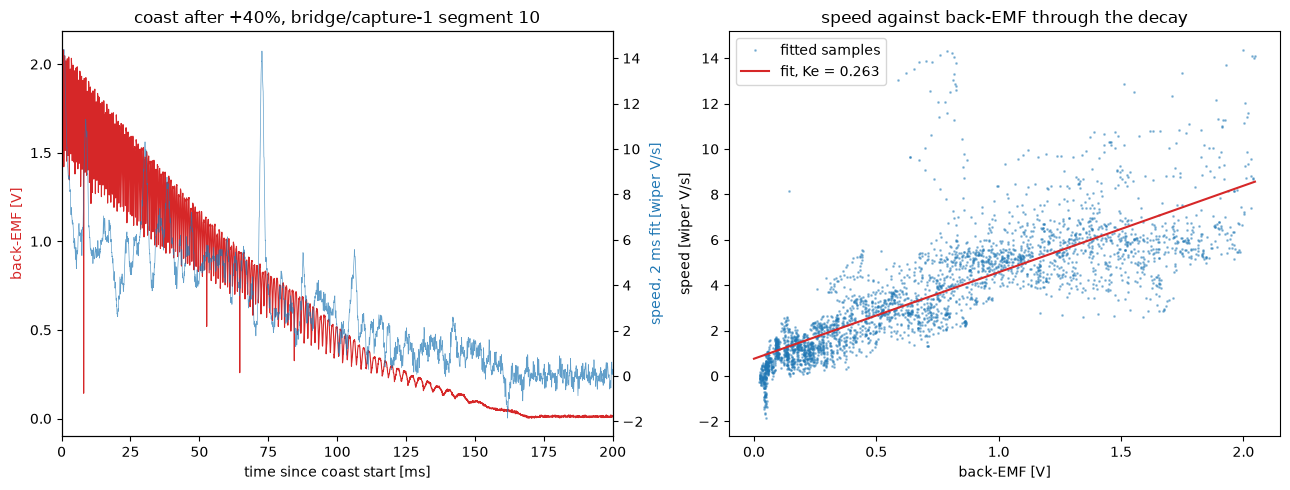

,samples_used,samples_fit,decay_ms,e_start_V,Ke_fit,w_intercept_Vps,Ke_integral
2,3332,3314,166.55,1.8611,0.2625,0.7615,0.2047


In [11]:
df_s, meta_s = spin["bridge/capture-1"]
seg_id = int(coasts[(coasts["recording"] == "bridge/capture-1")
                    & (coasts["direction"] == 1) & (coasts["drive_pct"] == 40)]["seg"].iloc[0])
seg = df_s[df_s["seg"] == seg_id]
t, pos, w, e, used, fit = coast_trace(seg)
row = coasts[(coasts["recording"] == "bridge/capture-1") & (coasts["seg"] == seg_id)].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(t[FIRST_SAMPLE:] * 1e3, e[FIRST_SAMPLE:], color="tab:red", lw=0.8)
ax.set_xlabel("time since coast start [ms]")
ax.set_ylabel("back-EMF [V]", color="tab:red")
ax2 = ax.twinx()
ax2.plot(t * 1e3, w, color="tab:blue", lw=0.5, alpha=0.7)
ax2.set_ylabel("speed, 2 ms fit [wiper V/s]", color="tab:blue")
ax.set_xlim(0, 200)
ax.set_title(f"coast after +40%, bridge/capture-1 segment {seg_id}")
ax = axes[1]
ax.plot(e[fit], w[fit], ".", ms=2, alpha=0.4, label="fitted samples")
ee = np.linspace(0, e[fit].max(), 10)
ax.plot(ee, ee / row["Ke_fit"] + row["w_intercept_Vps"], color="tab:red",
        label=f"fit, Ke = {row['Ke_fit']:.3f}")
ax.set_xlabel("back-EMF [V]")
ax.set_ylabel("speed [wiper V/s]")
ax.set_title("speed against back-EMF through the decay")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame([row[["samples_used", "samples_fit", "decay_ms", "e_start_V", "Ke_fit", "w_intercept_Vps", "Ke_integral"]]]).round(4)


The back-EMF starts at 1.9 V and decays to zero within about 170 ms.
The speed trace follows it with the pot's quantization noise on top. Both
traces carry a ripple of about 2 kHz at the start of the coast, 0.25 V
peak on the back-EMF. *Hypothesis (not tested here): this is the
commutation ripple of the motor.* The scatter is a line with the noise
spread along the speed axis and a positive speed intercept, the
within-coast form of the trend that section 7.3 reports across coasts.

### 7.3 All coast segments

Thirty coast segments, six per recording. The first table groups them by
direction and by the drive level that preceded the coast, which sets the
starting speed. The second pools each recording's six segments, with the
regression over all their used samples and the ratio of the summed
integrals to the summed travel.


In [12]:
grouped = coasts.groupby(["direction", "drive_pct"]).agg(
    segments=("seg", "size"),
    e_start_V=("e_start_V", lambda x: x.abs().mean()),
    Ke_fit_mean=("Ke_fit", "mean"),
    Ke_fit_std=("Ke_fit", "std"),
    Ke_integral_mean=("Ke_integral", "mean"),
    Ke_integral_std=("Ke_integral", "std"),
)
overall = pd.DataFrame({
    "segments": [len(coasts)],
    "e_start_V": [coasts["e_start_V"].abs().mean()],
    "Ke_fit_mean": [coasts["Ke_fit"].mean()],
    "Ke_fit_std": [coasts["Ke_fit"].std()],
    "Ke_integral_mean": [coasts["Ke_integral"].mean()],
    "Ke_integral_std": [coasts["Ke_integral"].std()],
}, index=pd.MultiIndex.from_tuples([("all", "all")], names=["direction", "drive_pct"]))
pd.concat([grouped, overall]).round(4)


segments  e_start_V  Ke_fit_mean  Ke_fit_std  \
direction drive_pct                                                 
-1        20.0              5     0.7029       0.1557      0.0189   
          30.0              5     1.0267       0.2103      0.0047   
          40.0              5     1.6991       0.2537      0.0115   
1         20.0              5     0.4123       0.2433      0.0631   
          30.0              5     0.9069       0.2135      0.0141   
          40.0              5     1.4782       0.2569      0.0033   
all       all              30     1.0377       0.2222      0.0436   

                     Ke_integral_mean  Ke_integral_std  
direction drive_pct                                     
-1        20.0                 0.1547           0.0069  
          30.0                 0.1865           0.0007  
          40.0                 0.2052           0.0025  
1         20.0                 0.1660           0.0185  
          30.0                 0.1933           0.0036  
          40.0                 0.2070           0.0034  
all       all                  0.1855           0.0211

In [13]:
rows = []
for name, (df, meta) in spin.items():
    es, ws = [], []
    for _, _, seg in coast_segments(df, meta):
        _, _, w, e, used, fit = coast_trace(seg)
        es.append(e[fit])
        ws.append(w[fit])
    es, ws = np.concatenate(es), np.concatenate(ws)
    slope, icpt = np.polyfit(es, ws, 1)
    c = coasts[coasts["recording"] == name]
    rows.append({"recording": name, "samples": len(es),
                 "Ke_regression": 1.0 / slope, "w_intercept_Vps": icpt,
                 "Ke_integral": c["integral_Vs"].abs().sum() / c["travel_V"].abs().sum()})
pooled_c = pd.DataFrame(rows).set_index("recording")
summary_c = pooled_c[["Ke_regression", "Ke_integral"]].agg(["mean", "std", "min", "max"]).T
summary_c["spread_pct"] = summary_c["std"] / summary_c["mean"] * 100
pd.concat([pooled_c.round(4), summary_c.round(4)], axis=0).fillna("")


,samples,Ke_regression,w_intercept_Vps,Ke_integral,mean,std,min,max,spread_pct
bridge/capture-1,13528.0,0.2125,-0.0558,0.1961,,,,,
bridge/capture-2,15678.0,0.2094,-0.0455,0.1926,,,,,
bridge/capture-3,15573.0,0.2117,-0.0263,0.1953,,,,,
bridge/capture-4,13727.0,0.2122,-0.0289,0.1944,,,,,
bridge/capture-5,14892.0,0.2089,-0.0814,0.195,,,,,
Ke_regression,,,,,0.2109,0.0016,0.2089,0.2125,0.7773
Ke_integral,,,,,0.1947,0.0013,0.1926,0.1961,0.6815


Findings:

- The per-segment integral rises with the starting speed of the coast,
  from 0.16 after a 20% step to 0.21 after a 40% step, with a spread
  inside each group of 1 to 11%. Forward and reverse agree within each
  group to a few percent.
- The per-segment regression scatters more (20% overall) and sits above
  the integral. The 2 ms derivative carries the pot quantization and the
  ripple, and the short 20% coasts, 50 to 90 ms of decay, give it the
  least to work with. The integral needs no derivative and is the figure
  to trust per segment.
- Pooled per recording, the integral ratio gives 0.195 and the regression
  0.210, each repeating to under 1% across the five recordings. The pooled
  figures weight the long, fast 40% coasts most, which is why they sit
  above the per-segment mean of 0.19.

## 8. Agreement

The table collects every estimate with its spread. The spread of route A
is the recording spread of the joint fit, which section 5.3 showed to be
the collinearity. Route C is listed per segment (30 segments) and pooled
per recording (5 recordings).


In [14]:
a_joint = fits_a["Ke_V_per_Vps"]
rows = [
    {"route": "A joint fit", "Ke": a_joint.mean(), "std": a_joint.std(), "n": len(a_joint), "n_unit": "recordings"},
    {"route": "A with R fixed at the joint median", "Ke": ke_fixed.mean(), "std": ke_fixed.std(), "n": len(ke_fixed), "n_unit": "recordings"},
    {"route": "C regression, per segment", "Ke": coasts["Ke_fit"].mean(), "std": coasts["Ke_fit"].std(), "n": len(coasts), "n_unit": "coast segments"},
    {"route": "C integral, per segment", "Ke": coasts["Ke_integral"].mean(), "std": coasts["Ke_integral"].std(), "n": len(coasts), "n_unit": "coast segments"},
    {"route": "C regression, pooled per recording", "Ke": pooled_c["Ke_regression"].mean(), "std": pooled_c["Ke_regression"].std(), "n": len(pooled_c), "n_unit": "recordings"},
    {"route": "C integral, pooled per recording", "Ke": pooled_c["Ke_integral"].mean(), "std": pooled_c["Ke_integral"].std(), "n": len(pooled_c), "n_unit": "recordings"},
]
agree = pd.DataFrame(rows).set_index("route")
agree["spread_pct"] = agree["std"] / agree["Ke"] * 100
agree["vs_A_joint_pct"] = (agree["Ke"] / a_joint.mean() - 1) * 100
agree["ratio_A_to_route"] = a_joint.mean() / agree["Ke"]
agree.round(4)


,Ke,std,n,n_unit,spread_pct,vs_A_joint_pct,ratio_A_to_route
route,,,,,,,
A joint fit,0.3461,0.0209,15,recordings,6.0482,0.0000,1.0000
A with R fixed at the joint median,0.3482,0.0012,15,recordings,0.3572,0.6080,0.9940
"C regression, per segment",0.2222,0.0436,30,coast segments,19.6319,-35.7812,1.5572
"C integral, per segment",0.1855,0.0211,30,coast segments,11.3619,-46.4123,1.8661
"C regression, pooled per recording",0.2109,0.0016,5,recordings,0.7773,-39.0516,1.6407
"C integral, pooled per recording",0.1947,0.0013,5,recordings,0.6815,-43.7437,1.7776


**Verdict.** The two routes do not agree. Route C reads 35 to 46% below
route A depending on the estimator, a gap of six or more route-A spreads,
and the residual valley of section 5.3 cannot close it, since even the low
end of the valley, $K_e$ = 0.30, sits 40 to 55% above route C. Two independent
routes agreeing within their stated uncertainty was the acceptance rule
for a measured $K_e$, and it is not met.

The ratio between the routes is 1.5 to 1.9. *Hypothesis (not tested
here): the coast reading is a divided fraction of the back-EMF. With the
bridge open, the winding floats between two equal 30 kOhm dividers to
ground, so the back-EMF splits symmetrically, $+e/2$ on one terminal and
$-e/2$ on the other, and the negative side reads zero. The route C values
would then be $K_e/2$, giving 0.39 to 0.42 against route A's 0.35, at the
upper edge of the residual valley. The rise of the per-segment constant
with starting speed fits the same picture, since once the negative
terminal reaches the pin clamp voltage the split stops being symmetric and
the positive side reads a larger fraction. The test is a direct measurement
of both terminals during a coast with an instrument that does not clamp.*

Until that measurement exists, route A's 0.35 V per wiper V/s, with its
0.30 to 0.40 valley, is the only unconditional estimate, and route C's
0.19 to 0.21 stands as the measured floating-terminal voltage per unit of
speed, whatever fraction of the back-EMF it turns out to be.

## 9. Limitations and open issues

- **Nominal VDD.** $R$ and every voltage scale with the true VDD of this
  unit, which was not measured. $K_e$ is a ratio of two VDD-referenced
  voltages and is unaffected.
- **One servo, one supply.** All numbers describe this one unit on a
  2-cell battery.
- **Route A collinearity.** Current and speed are 99.8% correlated across
  the grid. $R$ is not measured here, and $K_e$ from route A carries a
  0.30 to 0.40 valley on top of its recording spread. Separating the two
  needs steps at the same speed and different currents, or a locked-rotor
  measurement.
- **Route A speeds.** The slowest steps have not reached steady speed at
  the end of the 80 ms window (notebook 00, section 7), so their speeds
  read low and the residuals are structured.
- **Floating-terminal reading.** One terminal reads zero during every
  coast. Whether the other terminal reads the full back-EMF or a divided
  fraction is the open question of section 8, and it decides whether the
  two routes agree.
- **Rejected candidate.** The fast-decay crest sample reads a
  current-dependent transient on the terminal driven low at 10% to 40%
  duty. In this scan geometry it is not a back-EMF channel.
- **Gear ratio unknown.** $K_e$ is referenced to the pot wiper. The motor
  shaft constant is this value times the wiper volts per motor radian,
  which requires the gear ratio and the pot's volts per radian.

## 10. What later notebooks use

- $K_e$ = 0.35 V per wiper V/s from route A, with the 0.30 to 0.40
  valley, until the floating-terminal question is closed.
- The route A combination $R + 34\,K_e \approx 13.5$ Ohm, which is what
  the steady-state drive data pins.
- The floating-terminal voltage per unit of speed from the coast segments,
  0.195 V per wiper V/s by the integral ratio and 0.210 by regression,
  pooled per recording.
- The current-offset subtraction and the per-step supply estimate of
  notebook 00, reused here unchanged.
- The coast-segment convention of section 7 (terminal driven high in the
  preceding step, third sample onward, 2 ms centred derivative, speed
  regressed on back-EMF, integral cross-check), ready to rerun once the
  divider question is settled.
- The fast-decay crest sample is a current channel in the OFF portion, and
  nothing downstream should read it as back-EMF.
